In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense,Dropout
from tensorflow.keras import Input

In [ ]:
import pandas as pd

project_path = "/content/drive/MyDrive/student_dropout_project"

df = pd.read_csv(project_path + "/data/processed_data.csv")

df.head()

,School,Gender,Age,Address,Family_Size,Parental_Status,Mother_Education,Father_Education,Mother_Job,Father_Job,...,Free_Time,Going_Out,Weekend_Alcohol_Consumption,Weekday_Alcohol_Consumption,Health_Status,Number_of_Absences,Grade_1,Grade_2,Final_Grade,Dropped_Out
0,0,0,18,1,0,0,4,4,0,4,...,3,4,1,1,3,4,0,11,11,False
1,0,0,17,1,0,1,1,1,0,2,...,3,3,1,1,3,2,9,11,11,False
2,0,0,15,1,1,1,1,1,0,2,...,3,2,2,3,3,6,12,13,12,False
3,0,0,15,1,0,1,4,2,1,3,...,2,2,1,1,5,0,14,14,14,False
4,0,0,16,1,0,1,3,3,2,2,...,3,2,1,2,5,0,11,13,13,False


In [ ]:
leak_cols = ["Grade_1", "Grade_2", "Final_Grade", "Number_of_Failures"]

df_clean = df.drop(columns=leak_cols)

In [ ]:
X = df_clean.drop("Dropped_Out", axis=1)
y = df_clean["Dropped_Out"]

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [ ]:
from imblearn.over_sampling import SMOTE

sm = SMOTE(random_state=42)
X_train_s, y_train_s = sm.fit_resample(X_train, y_train)

print("Before:\n", y_train.value_counts())
print("After:\n", y_train_s.value_counts())

Before:
 Dropped_Out
False    439
True      80
Name: count, dtype: int64
After:
 Dropped_Out
False    439
True     439
Name: count, dtype: int64


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV

params_lr = {
    'C': [0.01, 0.1, 1, 10],
    'penalty': ['l2'],
    'class_weight': ['balanced', None],
    'solver': ['lbfgs']
}

lr = LogisticRegression(max_iter=500)
lr_search = GridSearchCV(lr, params_lr, cv=3, scoring='f1_macro')
lr_search.fit(X_train_s, y_train_s)

print("Best LR Params:", lr_search.best_params_)
best_lr = lr_search.best_estimator_

Best LR Params: {'C': 0.1, 'class_weight': 'balanced', 'penalty': 'l2', 'solver': 'lbfgs'}


In [ ]:
from sklearn.metrics import accuracy_score, classification_report

y_pred_lr = best_lr.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr))

Accuracy: 0.7692307692307693
              precision    recall  f1-score   support

       False       0.88      0.84      0.86       110
        True       0.31      0.40      0.35        20

    accuracy                           0.77       130
   macro avg       0.60      0.62      0.60       130
weighted avg       0.80      0.77      0.78       130



In [ ]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier
import numpy as np

param_dist_rf = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [5, 10, 15, 20, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'class_weight': ['balanced', 'balanced_subsample']
}

rf = RandomForestClassifier(random_state=42)
rf_search = RandomizedSearchCV(rf, param_dist_rf, n_iter=20, cv=3, scoring='f1_macro', n_jobs=-1)
rf_search.fit(X_train_s, y_train_s)

print("Best RF Params:", rf_search.best_params_)
best_rf = rf_search.best_estimator_

Best RF Params: {'n_estimators': 300, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_depth': 20, 'class_weight': 'balanced_subsample'}


In [ ]:
from sklearn.metrics import accuracy_score, classification_report

y_pred_rf = best_rf.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

Accuracy: 0.8076923076923077
              precision    recall  f1-score   support

       False       0.88      0.90      0.89       110
        True       0.35      0.30      0.32        20

    accuracy                           0.81       130
   macro avg       0.61      0.60      0.61       130
weighted avg       0.80      0.81      0.80       130



In [ ]:
import xgboost as xgb
from sklearn.model_selection import RandomizedSearchCV

param_dist_xgb = {
    'max_depth': [3, 4, 5, 6],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'n_estimators': [100, 200, 300],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0],
    'scale_pos_weight': [4, 5, 6]
}

xgb_clf = xgb.XGBClassifier(random_state=42, eval_metric='logloss')
xgb_search = RandomizedSearchCV(xgb_clf, param_dist_xgb, n_iter=25, cv=3, scoring='f1_macro', n_jobs=-1)

xgb_search.fit(X_train_s, y_train_s)
print("Best XGB Params:", xgb_search.best_params_)
best_xgb = xgb_search.best_estimator_

Best XGB Params: {'subsample': 0.6, 'scale_pos_weight': 4, 'n_estimators': 300, 'max_depth': 6, 'learning_rate': 0.2, 'colsample_bytree': 0.6}


In [ ]:
from sklearn.metrics import accuracy_score, classification_report

y_pred_xgb = best_xgb.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_xgb))
print(classification_report(y_test, y_pred_xgb))

Accuracy: 0.7769230769230769
              precision    recall  f1-score   support

       False       0.87      0.86      0.87       110
        True       0.29      0.30      0.29        20

    accuracy                           0.78       130
   macro avg       0.58      0.58      0.58       130
weighted avg       0.78      0.78      0.78       130



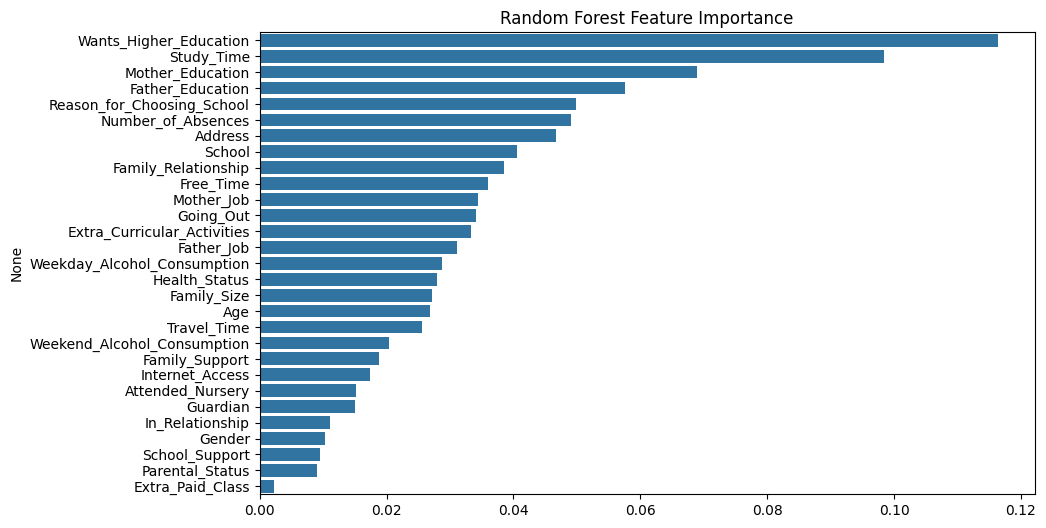

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

importances = best_rf.feature_importances_
indices = np.argsort(importances)[::-1]
features = X_train.columns

plt.figure(figsize=(10,6))
sns.barplot(x=importances[indices], y=features[indices])
plt.title("Random Forest Feature Importance")
plt.show()

In [ ]:
sample = X_test.iloc[21:22]

lr_pred = best_lr.predict(sample)[0]
rf_pred = best_rf.predict(sample)[0]

print("Logistic Regression Prediction:")
print("Dropout" if lr_pred else "Will Continue")

print("\nRandom Forest Prediction:")
print("Dropout" if rf_pred else "Will Continue")

Logistic Regression Prediction:
Will Continue

Random Forest Prediction:
Will Continue


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled_s = scaler.fit_transform(X_train_s)
X_test_scaled = scaler.transform(X_test)

In [ ]:
from tensorflow.keras import Input

ann = Sequential()

ann.add(Input(shape=(X_train_scaled_s.shape[1],)))

ann.add(Dense(64, activation='relu'))
ann.add(Dropout(0.3))

ann.add(Dense(32, activation='relu'))
ann.add(Dropout(0.3))

ann.add(Dense(16, activation='relu'))
ann.add(Dense(1, activation='sigmoid'))

ann.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

ann.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_1 (Dense)                 │ (None, 64)             │         1,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,545 (17.75 KB)

 Trainable params: 4,545 (17.75 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

In [ ]:
history = ann.fit(
    X_train_scaled_s,
    y_train_s,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - accuracy: 0.6250 - loss: 0.6900 - val_accuracy: 0.1420 - val_loss: 0.8593
Epoch 2/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6367 - loss: 0.6015 - val_accuracy: 0.5114 - val_loss: 0.7434
Epoch 3/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7107 - loss: 0.5462 - val_accuracy: 0.7614 - val_loss: 0.6223
Epoch 4/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7817 - loss: 0.5089 - val_accuracy: 0.8352 - val_loss: 0.5138
Epoch 5/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7817 - loss: 0.4880 - val_accuracy: 0.8409 - val_loss: 0.4555
Epoch 6/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8075 - loss: 0.4371 - val_accuracy: 0.8352 - val_loss: 0.4593
Epoch 7/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8293 - loss: 0.4124 - val_accuracy: 0.8466 - val_loss: 0.3894
Epoch 8/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7972 - loss: 0.4437 - val_accuracy: 0.8636 - val_loss

In [ ]:
loss, accuracy = ann.evaluate(X_test_scaled, y_test)

print("ANN Test Accuracy:", accuracy)

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.8148 - loss: 0.4395
ANN Test Accuracy: 0.807692289352417


In [ ]:
y_pred_ann = ann.predict(X_test_scaled)
y_pred_ann = (y_pred_ann > 0.5).astype(int)

from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_ann))

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
              precision    recall  f1-score   support

       False       0.90      0.87      0.88       110
        True       0.39      0.45      0.42        20

    accuracy                           0.81       130
   macro avg       0.64      0.66      0.65       130
weighted avg       0.82      0.81      0.81       130



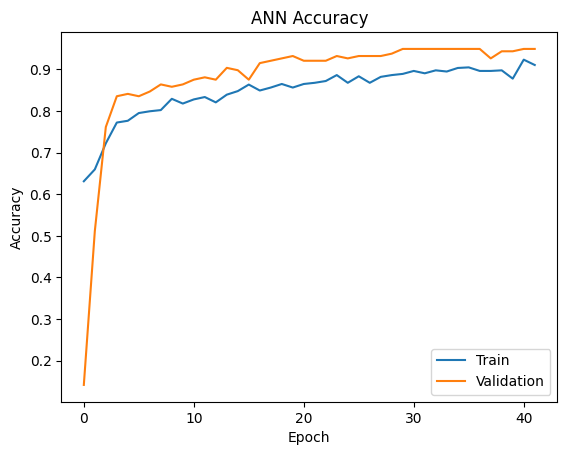

In [ ]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title("ANN Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend(["Train", "Validation"])
plt.show()

In [ ]:
from sklearn.metrics import classification_report

y_pred_ann = ann.predict(X_test_scaled)
y_pred_ann = (y_pred_ann > 0.5).astype(int)

print(classification_report(y_test, y_pred_ann))

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
              precision    recall  f1-score   support

       False       0.90      0.87      0.88       110
        True       0.39      0.45      0.42        20

    accuracy                           0.81       130
   macro avg       0.64      0.66      0.65       130
weighted avg       0.82      0.81      0.81       130



In [ ]:
# Same sample
sample = X_test.iloc[21:22]

# Scale the sample (VERY IMPORTANT)
sample_scaled = scaler.transform(sample)

# Get probability
ann_prob = ann.predict(sample_scaled)[0][0]

# Apply threshold (0.5 default)
ann_pred = 1 if ann_prob > 0.5 else 0

print("ANN Prediction:")
print("Dropout" if ann_pred == 1 else "Will Continue")

print("\nDropout Probability:", round(ann_prob, 3))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
ANN Prediction:
Will Continue

Dropout Probability: 0.155


In [ ]:
from sklearn.metrics import accuracy_score, f1_score, recall_score, precision_score
import pandas as pd

# Predictions
y_pred_lr = best_lr.predict(X_test)
y_pred_rf = best_rf.predict(X_test)
y_pred_xgb = best_xgb.predict(X_test)

y_prob_ann = ann.predict(X_test_scaled)
y_pred_ann = (y_prob_ann > 0.5).astype(int)

results = []

models = [
    ("Logistic Regression", y_pred_lr),
    ("Random Forest", y_pred_rf),
    ("XGBoost", y_pred_xgb),
    ("ANN (Deep Learning)", y_pred_ann)
]

for name, preds in models:
    results.append([
        name,
        accuracy_score(y_test, preds),
        precision_score(y_test, preds, average='macro'),
        recall_score(y_test, preds, average='macro'),
        f1_score(y_test, preds, average='macro')
    ])

comparison_df = pd.DataFrame(results,
                             columns=["Model", "Accuracy", "Precision", "Recall", "F1 Score"])

comparison_df = comparison_df.sort_values(by="F1 Score", ascending=False)

comparison_df

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step 


,Model,Accuracy,Precision,Recall,F1 Score
3,ANN (Deep Learning),0.807692,0.644250,0.661364,0.651699
1,Random Forest,0.807692,0.614524,0.600000,0.606108
0,Logistic Regression,0.769231,0.596154,0.618182,0.603820
2,XGBoost,0.776923,0.578637,0.581818,0.580131


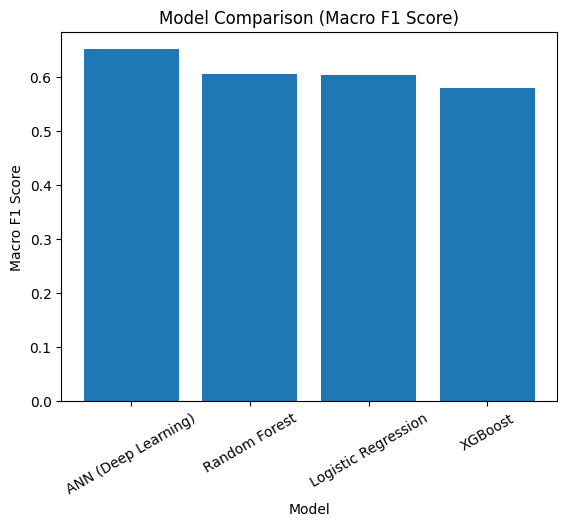

In [ ]:
import matplotlib.pyplot as plt

plt.figure()
plt.bar(comparison_df["Model"], comparison_df["F1 Score"])
plt.xlabel("Model")
plt.ylabel("Macro F1 Score")
plt.title("Model Comparison (Macro F1 Score)")
plt.xticks(rotation=30)
plt.show()

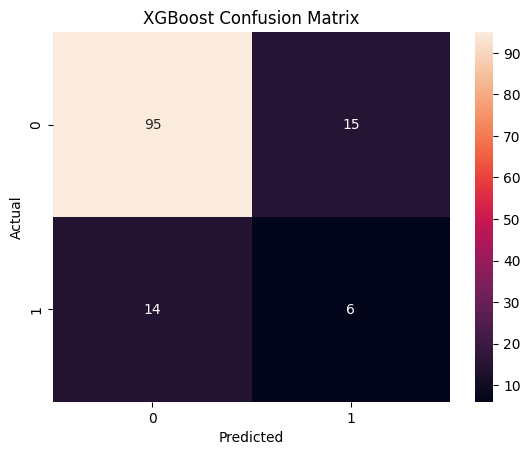

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_xgb)

plt.figure()
sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("XGBoost Confusion Matrix")
plt.show()

LR Accuracy: 0.7692307692307693
RF Accuracy: 0.8076923076923077
XGB Accuracy: 0.7769230769230769
ANN Accuracy: 0.8076923076923077


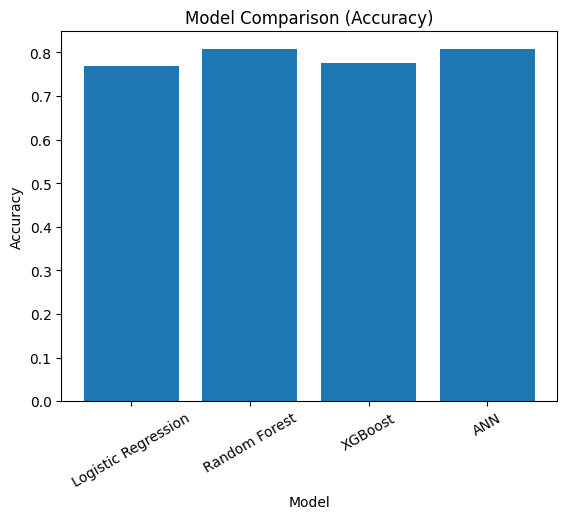

In [ ]:
from sklearn.metrics import accuracy_score

acc_lr = accuracy_score(y_test, y_pred_lr)
acc_rf = accuracy_score(y_test, y_pred_rf)
acc_xgb = accuracy_score(y_test, y_pred_xgb)
acc_ann = accuracy_score(y_test, y_pred_ann)

print("LR Accuracy:", acc_lr)
print("RF Accuracy:", acc_rf)
print("XGB Accuracy:", acc_xgb)
print("ANN Accuracy:", acc_ann)
import matplotlib.pyplot as plt

models = ["Logistic Regression", "Random Forest", "XGBoost", "ANN"]
accuracies = [acc_lr, acc_rf, acc_xgb, acc_ann]

plt.figure()
plt.bar(models, accuracies)
plt.xlabel("Model")
plt.ylabel("Accuracy")
plt.title("Model Comparison (Accuracy)")
plt.xticks(rotation=30)
plt.show()

In [ ]:
from xgboost import XGBClassifier

final_model = XGBClassifier(random_state=42)
final_model.fit(X_train_s, y_train_s)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, ...)

In [ ]:
from sklearn.metrics import accuracy_score, f1_score

y_pred_final = final_model.predict(X_test)

print("Final Accuracy:", accuracy_score(y_test, y_pred_final))
print("Final Macro F1:", f1_score(y_test, y_pred_final, average='macro'))

Final Accuracy: 0.8076923076923077
Final Macro F1: 0.5873015873015872


In [ ]:
from sklearn.metrics import f1_score

print("Final Macro F1:", f1_score(y_test, y_pred_final, average='macro'))

Final Macro F1: 0.5873015873015872


In [ ]:
import joblib
joblib.dump(final_model, "xgb_final_model.pkl")

['xgb_final_model.pkl']

In [ ]:
from google.colab import files
files.download("xgb_final_model.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
X_test.iloc[0]

,21
School,0
Gender,1
Age,15
Address,1
Family_Size,0
Parental_Status,1
Mother_Education,4
Father_Education,4
Mother_Job,1
Father_Job,1


In [51]:
sample = X_test.iloc[0]

prediction = final_model.predict([sample])

print("Prediction:", prediction[0])

Prediction: 0


In [52]:
import joblib

project_path = "/content/drive/MyDrive/student_dropout_project"

joblib.dump(
    final_model,
    project_path + "/models/best_model.pkl"
)

print("Best model saved in Drive ✅")

Best model saved in Drive ✅


In [53]:
joblib.dump(
    scaler,
    project_path + "/models/scaler.pkl"
)

print("Scaler saved in Drive ✅")

Scaler saved in Drive ✅


In [54]:
joblib.dump(
    X.columns,
    project_path + "/models/feature_columns.pkl"
)

print("Feature columns saved ✅")

Feature columns saved ✅


In [55]:
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

print("Final Accuracy:", accuracy_score(y_test, y_pred_final))
print("Final Macro F1:", f1_score(y_test, y_pred_final, average="macro"))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_final))

print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, y_pred_final))

Final Accuracy: 0.8076923076923077
Final Macro F1: 0.5873015873015872

Classification Report:

              precision    recall  f1-score   support

       False       0.87      0.91      0.89       110
        True       0.33      0.25      0.29        20

    accuracy                           0.81       130
   macro avg       0.60      0.58      0.59       130
weighted avg       0.79      0.81      0.80       130


Confusion Matrix:

[[100  10]
 [ 15   5]]


In [64]:
from google.colab import files

# Best Model
files.download("/content/drive/MyDrive/student_dropout_project/models/best_model.pkl")

# Scaler
files.download("/content/drive/MyDrive/student_dropout_project/models/scaler.pkl")

# Feature Columns
files.download("/content/drive/MyDrive/student_dropout_project/models/feature_columns.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [61]:
from google.colab import files

files.download("/content/drive/MyDrive/student_dropout_project/data/cleaned_data.csv")
files.download("/content/drive/MyDrive/student_dropout_project/data/processed_data.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>